In [67]:
from sbibm.tasks.two_moons.task import TwoMoons
import matplotlib.pyplot as plt
import pandas as pd
from sbibm.metrics import c2st,mmd,median_distance
import torch
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [68]:
task_name = 'twomoons'  # For sbibm.visualisation functions

In [69]:
posterior_samples = torch.load(f"posterior/{task_name}.pt")

In [70]:
task = TwoMoons()

In [71]:
df = []
for num_simulations, num_observation in posterior_samples.keys():
    posterior_samples_current = posterior_samples[(num_simulations, num_observation)]

    reference_samples = task.get_reference_posterior_samples(num_observation=num_observation)

    c2st_accuracy = c2st(reference_samples, posterior_samples_current).item()

    df.append({
        'num_simulations': num_simulations,
        'num_observation': num_observation,
        'Value': c2st_accuracy,
        'Metric': 'C2ST'
    })

    mmd2 = mmd(reference_samples, posterior_samples_current).item()

    df.append({
        'num_simulations': num_simulations,
        'num_observation': num_observation,
        'Value': mmd2,
        'Metric': 'MMD^2'
    })

    meddist = median_distance(reference_samples, posterior_samples_current).item()
    df.append({
        'num_simulations': num_simulations,
        'num_observation': num_observation,
        'Value': meddist,
        'Metric': 'MEDDIST'
    })

In [72]:
df = pd.DataFrame(df)
metrics = df['Metric'].unique()

In [73]:
df

,num_simulations,num_observation,Value,Metric
0,1000,1,0.997700,C2ST
1,1000,1,0.287881,MMD^2
2,1000,1,2.546685,MEDDIST
3,10000,1,0.969100,C2ST
4,10000,1,0.016246,MMD^2
5,10000,1,0.943322,MEDDIST
6,100000,1,0.930700,C2ST
7,100000,1,0.003388,MMD^2
8,100000,1,0.965133,MEDDIST


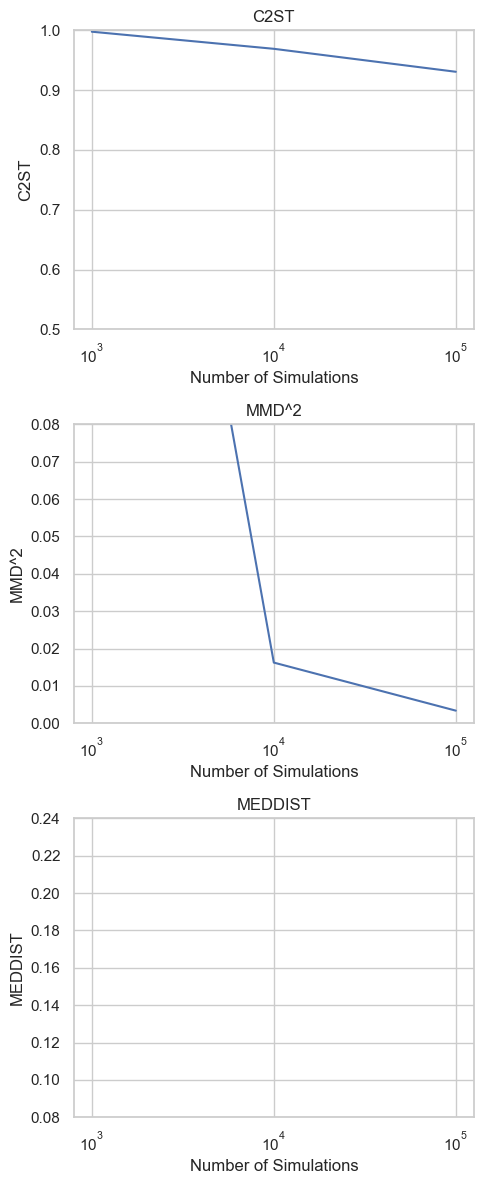

In [74]:
fig,axs = plt.subplots(len(metrics),1, figsize=(5,4*len(metrics)))

y_limits = {
    'C2ST': (0.5,1),
    'MMD^2': (0,0.08),
    'MEDDIST': (0.08,0.24)
}

for i, metric in enumerate(metrics):
    ax = axs[i]
    ax.set_title(metric)
    ax.set_ylim(y_limits[metric])
    ax.grid(True)

    sns.lineplot(
        data=df[df['Metric']==metric],
        x='num_simulations',
        y='Value',
        ax=ax
    )
    ax.set_xscale("log")
    ax.set_xlabel("Number of Simulations")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()